# Longitudinal modelling and plotting

This notebook introduces logitudinal modelling and plotting of its results available in the PCNToolkit


In [52]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from pcntoolkit import BLR, CorrelationMatrix, NormData, NormativeModel, ZDiffScore, ZGainScore
from pcntoolkit.math_functions.basis_function import BsplineBasisFunction
from pcntoolkit.util.plotter import plot_thrivelines

plt.rcParams.update({"figure.max_open_warning": 0})

CENTILES = [0.05, 0.25, 0.5, 0.75, 0.95]
Z_ANCHORS = stats.norm.ppf(CENTILES)
COVARIATE = "age"


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Data and model

We start with a reference model fitted on a cross-sectional dataset and then transfer it to a longitudinal cohort. This gives us z-scores for repeated measures, which are the basic inputs for the downstream change scores.


In [53]:
def find_data_dir():
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / "pcntoolkit_resources" / "data"
        if (candidate / "fcon1000.csv").exists() and (candidate / "LNM_data.csv").exists():
            return candidate
    raise FileNotFoundError("Could not find pcntoolkit_resources/data with fcon1000.csv and LNM_data.csv")

def tidy_region_names(df):
    return df.rename(columns={
        c: c.replace("&", "_and_").replace("_thickness", "") for c in df.columns
    })

data_dir = find_data_dir()
response_vars = ["rh_S_front_sup", "rh_G_front_middle"]

print("Using data_dir =", data_dir)
print("Response vars =", response_vars)


Using data_dir = /home/preclineu/marglu/Desktop/PCNtoolkit/pcntoolkit_resources/data
Response vars = ['rh_S_front_sup', 'rh_G_front_middle']


In [54]:
reference_df = tidy_region_names(pd.read_csv(data_dir / "fcon1000.csv"))
reference_data = NormData.from_dataframe(
    name="reference",
    dataframe=reference_df,
    covariates=["age"],
    batch_effects=["site", "sex"],
    response_vars=response_vars,
    subject_ids="sub_id",
)

fcon1000_model = NormativeModel(
    BLR(
        basis_function_mean=BsplineBasisFunction(degree=3, nknots=5),
        warp_name="warpsinharcsinh",
    ),
    inscaler="standardize",
    outscaler="standardize",
    savemodel=False,
    saveresults=False,
)

fcon1000_model.fit(reference_data)
print("Reference model fitted")


Process: 1075104 - 2026-08-30 22:05:41 - Dataset "reference" created.
    - 1078 observations
    - 1078 unique subjects
    - 1 covariates
    - 2 response variables
    - 2 batch effects:
    	site (23)
	sex (2)
    
Process: 1075104 - 2026-08-30 22:05:41 - Fitting models on 2 response variables.
Process: 1075104 - 2026-08-30 22:05:41 - Fitting model for rh_S_front_sup.
Process: 1075104 - 2026-08-30 22:05:42 - Fitting model for rh_G_front_middle.
Process: 1075104 - 2026-08-30 22:05:42 - Making predictions on 2 response variables.
Process: 1075104 - 2026-08-30 22:05:42 - Computing z-scores for 2 response variables.
Process: 1075104 - 2026-08-30 22:05:42 - Computing z-scores for rh_G_front_middle.
Process: 1075104 - 2026-08-30 22:05:42 - Computing z-scores for rh_S_front_sup.
Process: 1075104 - 2026-08-30 22:05:42 - Computing centiles for 2 response variables.
Process: 1075104 - 2026-08-30 22:05:42 - Computing centiles for rh_G_front_middle.
Process: 1075104 - 2026-08-30 22:05:42 - Com

In [55]:
longitudinal_df = tidy_region_names(pd.read_csv(data_dir / "LNM_data.csv"))

control_df = longitudinal_df[longitudinal_df["group"] == "control"]
patient_df = longitudinal_df[longitudinal_df["group"] == "patient"]

control_data = NormData.from_dataframe(
    name="control",
    dataframe=control_df,
    covariates=["age"],
    batch_effects=["site", "sex"],
    response_vars=response_vars,
    subject_ids="sub_id",
    visits="visit",
)

patient_data = NormData.from_dataframe(
    name="patient",
    dataframe=patient_df,
    covariates=["age"],
    batch_effects=["site", "sex"],
    response_vars=response_vars,
    subject_ids="sub_id",
    visits="visit",
)

control_adapt, control_test = control_data.train_test_split(splits=[0.2, 0.8])
lnm_model = fcon1000_model.transfer(control_adapt)
lnm_model.predict(control_test)
lnm_model.predict(patient_data)

print("Control subjects:", control_df["sub_id"].nunique())
print("Patient subjects:", patient_df["sub_id"].nunique())


Process: 1075104 - 2026-08-30 22:05:45 - Dataset "control" created.
    - 134 observations
    - 67 unique subjects
    - 1 covariates
    - 2 response variables
    - 2 batch effects:
    	site (1)
	sex (2)
    
Process: 1075104 - 2026-08-30 22:05:45 - Dataset "patient" created.
    - 196 observations
    - 98 unique subjects
    - 1 covariates
    - 2 response variables
    - 2 batch effects:
    	site (1)
	sex (2)
    
Process: 1075104 - 2026-08-30 22:05:45 - Transferring models on 2 response variables.
Process: 1075104 - 2026-08-30 22:05:45 - Transferring model for rh_G_front_middle.
Process: 1075104 - 2026-08-30 22:05:45 - Transferring model for rh_S_front_sup.
Process: 1075104 - 2026-08-30 22:05:45 - Saving model to:
	/home/preclineu/marglu/.pcntoolkit/saves_transfer.
Process: 1075104 - 2026-08-30 22:05:45 - Making predictions on 2 response variables.
Process: 1075104 - 2026-08-30 22:05:45 - Computing z-scores for 2 response variables.
Process: 1075104 - 2026-08-30 22:05:45 - Com

### Visualize the longitudinal dataset

Each subject in the longitudinal cohort has two visits. We can therefore draw one line per subject to show how the measurement changes between the first and second visit.

This gives a quick visual check before we move to the change scores.


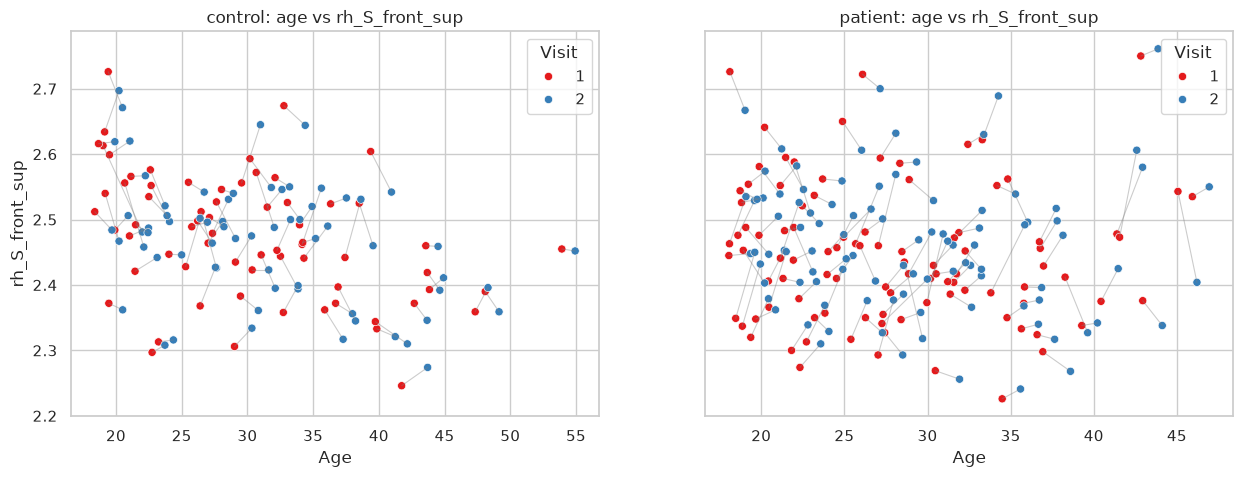

In [56]:
feature_to_plot = response_vars[0]
groups = {"control": control_df, "patient": patient_df}

fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for axis, (group_name, group_df) in zip(ax, groups.items()):
    for _, subject_rows in group_df.groupby("sub_id"):
        ordered = subject_rows.sort_values("visit")
        axis.plot(ordered["age"], ordered[feature_to_plot], color="grey", alpha=0.4, lw=0.8)
    sns.scatterplot(
        data=group_df,
        x="age",
        y=feature_to_plot,
        hue="visit",
        palette="Set1",
        s=35,
        ax=axis,
    )
    axis.legend(title="Visit")
    axis.set_title(f"{group_name}: age vs {feature_to_plot}")
    axis.set_xlabel("Age")
    axis.set_ylabel(feature_to_plot)
plt.show()


## 2. Correlation matrix

The age-to-age correlation matrix is the piece that is used for calculating and visualizing longitudinal change. It summarises how z-scores at one age relate to z-scores at another age.


We can compute this matrix from a longitudinal reference cohort, and later in this tutorial we will also show the workflow how can a matrix be loaded directly from a saved object. In other words, the matrix can be estimated once and then reused as a public shared resource.

### When to use which object?

| Goal | Use | Why |
|------|-----|-----|
| Compare a subject’s score at two visits | `z-diff` | Simple direct difference between two z-scores |
| Ask whether later change is abnormal given prior value and age-to-age dependence | `z-gain` | Uses the age-to-age correlation matrix and is conditional on the earlier score |
| Describe expected forward movement over age | `thrivelines` | Propagates trajectories from the correlation matrix and maps them back to the measurement scale |

In [57]:
corr = CorrelationMatrix.compute(
    control_test,
    bandwidth=3,
    covariate="age",
)

print("bandwidth:", corr.bandwidth)
print("n_subjects:", corr.n_subjects)
print("estimated_range:", corr.estimated_range)


bandwidth: 3
n_subjects: 66
estimated_range: (18, 54)


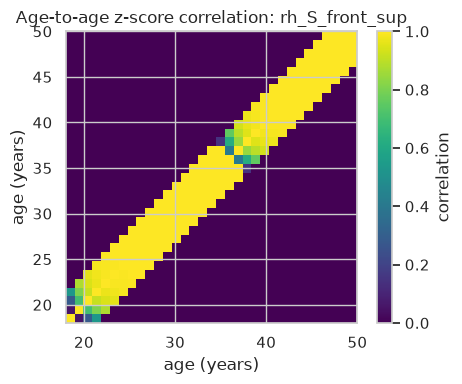

In [58]:
region = response_vars[0]
R = corr.matrix.sel(response_vars=region)
age_lo, age_hi = 18, 50
R = R.sel(age_1=slice(age_lo, age_hi), age_2=slice(age_lo, age_hi))

plt.figure(figsize=(5, 4))
plt.imshow(R.values, origin="lower", extent=[age_lo, age_hi, age_lo, age_hi], vmin=0, vmax=1, cmap="viridis")
plt.colorbar(label="correlation")
plt.xlabel("age (years)")
plt.ylabel("age (years)")
plt.title(f"Age-to-age z-score correlation: {region}")
plt.tight_layout()
plt.show()


## 3. z-diff and z-gain

Now that the model and the correlation structure are in place, we can score subject-level change. This is where the package exposes the current functionality directly.

The important distinction is:

- z-diff is the raw difference between two z-scores. 
- z-gain is conditional on the earlier z-score and the age-to-age correlation. It asks whether the later z-score is more extreme than expected under the reference relationship.

So the two scores are different measures, but they are both valid summary measures for longitudinal change in this package.

### `ZGainScore` attributes

| Attribute | Filled by | Meaning |
|-----------|-----------|---------|
| `zgain.zgain` | `score()` | The subject-level z-gain values for the scored data |
| `zgain.thrivelines` | `get_thrivelines()` | The DataFrame containing the computed thriveline trajectories |
| `zgain.model` | constructor | The fitted normative model used to map z-space back to the response space |
| `zgain.correlation_matrix` | constructor | The age-to-age correlation object used in the conditional score |

These attributes are cached on the object. If you call `score()` or `get_thrivelines()` once, the results are stored and can be reused without re-running the full computation.


In [59]:
zdiff = ZDiffScore(
    normative_model=lnm_model,
    reference_data=control_test,
    subject_id_col="sub_id",
)
zdiff_scores = zdiff.score(score_data=patient_data, subject_id_col="sub_id")

zgain = ZGainScore(lnm_model, corr)
zgain_scores = zgain.score(score_data=patient_data)

print(f"z-diff summary: {zdiff_scores.to_dataframe(name='z_diff').unstack('response_vars').head()}")
print(f"z-gain summary: {zgain_scores.to_dataframe(name='z_gain').unstack('response_vars').head()}")


z-diff summary:                       z_diff                  
response_vars rh_S_front_sup rh_G_front_middle
subjects                                      
P000               -0.322964         -0.565736
P001               -2.297495         -2.848406
P002               -0.516952         -0.229765
P003                0.494147          1.133814
P004                0.192776         -0.492138
z-gain summary:                       z_gain                  
response_vars rh_S_front_sup rh_G_front_middle
subjects                                      
P000               -1.218579         -1.453539
P001               -7.754113         -6.219977
P002               -1.012166         -0.517759
P003                1.568706          2.982843
P004                0.860851         -0.970241


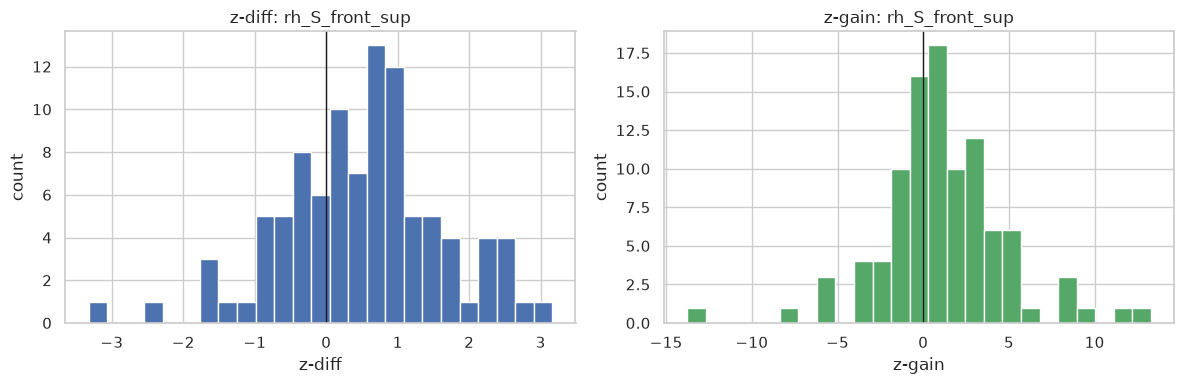

In [60]:
zd = zdiff_scores.sel(response_vars=region).values
zg = zgain_scores.sel(response_vars=region).values

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(zd, bins=25, color="#4c72b0", edgecolor="white")
ax[0].axvline(0, color="k", lw=1)
ax[0].set_xlabel("z-diff")
ax[0].set_ylabel("count")
ax[0].set_title(f"z-diff: {region}")

ax[1].hist(zg, bins=25, color="#55a868", edgecolor="white")
ax[1].axvline(0, color="k", lw=1)
ax[1].set_xlabel("z-gain")
ax[1].set_ylabel("count")
ax[1].set_title(f"z-gain: {region}")
plt.tight_layout()
plt.show()


## 4. Thrivelines

The final stage is to turn the age-to-age correlation structure into expected future change of the measure. Thrivelines do exactly that. They propagate a set of starting ages and starting z-scores through the correlation matrix and map the result back to the measurement scale using the normative model.

This shows the expected trajectory of a subject relative to the normative centile curves

### Structure of the thrivelines dataset

`zgain.get_thrivelines()` returns a long-form pandas table. Each row is one point on one trajectory segment.

| Column | Meaning |
|--------|---------|
| `segment` | Identifier for a single anchor trajectory |
| `response_var` | Brain region or variable being traced |
| `offset` | Position along the segment; values increase as the trajectory moves forward in age |
| `X` | Covariate value, usually age |
| `Z` | Z-score value along the trajectory |
| `Y` | Corresponding value in the original measurement space |


In [61]:
thrivelines = zgain.get_thrivelines(
    z_anchor_start=-2,
    z_anchor_end=3,
    covariate_range=(18, 50),
    z_anchors=Z_ANCHORS,
)

region_df = thrivelines[thrivelines["response_var"] == region]
print("Thrivelines rows:", len(thrivelines))
thrivelines.head()


Thrivelines rows: 640


,segment,start_age,start_z,response_var,offset,X,Z,Y
0,0,18.0,-1.644854,rh_S_front_sup,0,18.0,-1.644854,2.446782
1,0,18.0,-1.644854,rh_S_front_sup,1,19.0,-2.042630,2.394818
2,1,18.0,-0.674490,rh_S_front_sup,0,18.0,-0.674490,2.531742
3,1,18.0,-0.674490,rh_S_front_sup,1,19.0,-1.992329,2.399776
4,2,18.0,0.000000,rh_S_front_sup,0,18.0,0.000000,2.591441


Process: 1075104 - 2026-08-30 22:05:57 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	site (1)
	sex (1)
    
Process: 1075104 - 2026-08-30 22:05:57 - Computing centiles for 1 response variables.
Process: 1075104 - 2026-08-30 22:05:57 - Computing centiles for rh_S_front_sup.


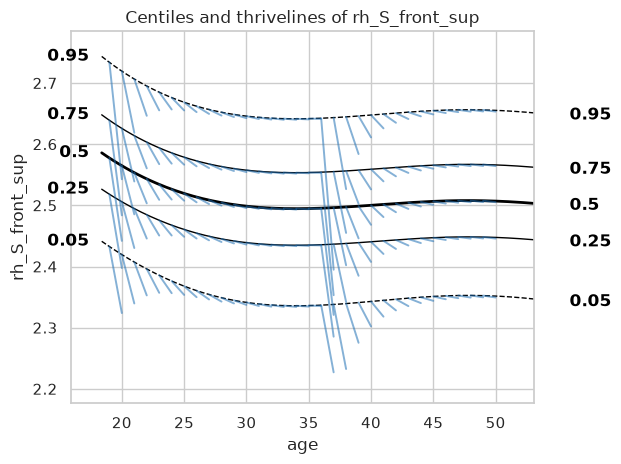

[<Figure size 640x480 with 1 Axes>]

In [62]:
plot_thrivelines(
    lnm_model,
    thrivelines=thrivelines,
    centiles=CENTILES,
    response_vars=[region],
    covariate=COVARIATE,
)


## 5. Loading a public shared correlation matrix

The same package functionality also works when the correlation matrix is already saved and shared as a public resource. In that case, the user starts from the matrix rather than from the raw longitudinal data

In [63]:
import glob
import os
import pickle
import re

import numpy as np
import xarray as xr
from scipy import stats
from scipy.sparse import spmatrix

from pcntoolkit.math_functions.velocity import compute_thrivelines, compute_thriveline_y, thrivelines_to_dataframe
from pcntoolkit.util.plotter import plot_thrivelines

public_model = NormativeModel.load(path="/home/preclineu/marglu/Downloads/HBR_Sb_ct_DES_lifespan_79K_100sites")

BASE_DIR = '/project_cephfs/3022017.06/projects/lifespan_hbr/johbay/Velocity/Velocity_models/DES_retrain'
N_REGIONS = 10
ref_path = '/project_cephfs/3022017.06/projects/lifespan_hbr/johbay/Velocity_CODE_public/DATA_For_Public_Models/DES/train_retrain_full_models_DES_adults_ADNI.pkl'

reference_data = pickle.load(open(ref_path, 'rb'))
print('reference_data loaded; columns:', getattr(reference_data, 'columns', None))

candidates = [os.path.join(BASE_DIR, entry) for entry in os.listdir(BASE_DIR) if os.path.isdir(os.path.join(BASE_DIR, entry))]
region_pkls = {}
for folder in candidates:
    pkl_list = sorted(glob.glob(os.path.join(folder, '**', '*.pkl'), recursive=True))
    if not pkl_list:
        continue
    velocity_pkls = [p for p in pkl_list if 'velocity' in os.path.basename(p).lower()]
    pick = velocity_pkls[0] if velocity_pkls else pkl_list[0]
    region_pkls[os.path.basename(folder)] = pick

if not region_pkls:
    raise RuntimeError(f'No pickles found under {BASE_DIR}')

selected = sorted(region_pkls.items())[:N_REGIONS]
print('Selected regions:')
for name, p in selected:
    print('-', name, '->', p)


/home/preclineu/marglu/Desktop/PCNtoolkit/pcntoolkit/util/output.py:295: UserWarning: Process: 1075104 - 2026-08-30 22:05:57 - This model was saved with PCNtoolkit v1.1.1, but you are running v1.2.0.post1. Loading this model in v1.2.0.post1...
  warnings.warn(message, category)
/home/preclineu/marglu/Desktop/PCNtoolkit/pcntoolkit/util/output.py:295: UserWarning: Process: 1075104 - 2026-08-30 22:05:57 - This model was saved with PCNtoolkit v1.1.1, but you are running v1.2.0.post1. Loading this model in v1.2.0.post1...
  warnings.warn(message, category)
/home/preclineu/marglu/Desktop/PCNtoolkit/pcntoolkit/util/output.py:295: UserWarning: Process: 1075104 - 2026-08-30 22:05:58 - This model was saved with PCNtoolkit v1.1.1, but you are running v1.2.0.post1. Loading this model in v1.2.0.post1...
  warnings.warn(message, category)
/home/preclineu/marglu/Desktop/PCNtoolkit/pcntoolkit/util/output.py:295: UserWarning: Process: 1075104 - 2026-08-30 22:05:58 - This model was saved with PCNtoolkit

reference_data loaded; columns: Index(['lh_G_and_S_frontomargin', 'lh_G_and_S_occipital_inf',
       'lh_G_and_S_paracentral', 'lh_G_and_S_subcentral',
       'lh_G_and_S_transv_frontopol', 'lh_G_and_S_cingul-Ant',
       'lh_G_and_S_cingul-Mid-Ant', 'lh_G_and_S_cingul-Mid-Post',
       'lh_G_cingul-Post-dorsal', 'lh_G_cingul-Post-ventral',
       ...
       'age', 'sex', 'site', 'site_id', 'ID_visit', 'ID_subject',
       'Mean_Thickness', 'Median_Thickness', 'which_dataset', 'site_id2'],
      dtype='object', length=158)
Selected regions:
- batch_100_rh_G_pariet_inf-Supramar -> /project_cephfs/3022017.06/projects/lifespan_hbr/johbay/Velocity/Velocity_models/DES_retrain/batch_100_rh_G_pariet_inf-Supramar/Velocity/velocity_objects_new_Oct25.pkl
- batch_101_rh_G_parietal_sup -> /project_cephfs/3022017.06/projects/lifespan_hbr/johbay/Velocity/Velocity_models/DES_retrain/batch_101_rh_G_parietal_sup/Velocity/velocity_objects_new_Oct25.pkl
- batch_102_rh_G_postcentral -> /project_cephfs/302

/home/preclineu/marglu/Desktop/PCNtoolkit/pcntoolkit/util/output.py:295: UserWarning: Process: 1075104 - 2026-08-30 22:07:10 - This model was saved with PCNtoolkit v1.1.1, but you are running v1.2.0.post1. Loading this model in v1.2.0.post1...
  warnings.warn(message, category)
/scratch/marglu/slurm_job_55098950/ipykernel_1075104/2318168885.py:20: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  reference_data = pickle.load(open(ref_path, 'rb'))


In [64]:
centiles = [0.05, 0.25, 0.5, 0.75, 0.95]
z_anchors = stats.norm.ppf(centiles)

all_thrivelines = []
for folder_name, pkl_path in selected:
    print('---')
    print('Region folder:', folder_name)
    with open(pkl_path, 'rb') as f:
        jb_obj = pickle.load(f)

    jb = None
    if isinstance(jb_obj, dict):
        if 'A_sparse_predict' in jb_obj:
            jb = jb_obj['A_sparse_predict']
        else:
            for v in jb_obj.values():
                if isinstance(v, spmatrix):
                    jb = v
                    break
    else:
        jb = jb_obj

    if jb is None:
        raise ValueError(f'Could not locate a sparse matrix in the pickle for {folder_name}')

    corr_dense = jb.toarray() if hasattr(jb, 'toarray') else np.asarray(jb)
    R = xr.DataArray(
        corr_dense,
        dims=('dim_1', 'dim_2'),
        coords={'dim_1': np.arange(corr_dense.shape[0]), 'dim_2': np.arange(corr_dense.shape[1])},
    )

    candidate_region = re.sub(r'^batch_\d+_', '', folder_name)
    region = candidate_region
    if region not in getattr(public_model, 'response_vars', []):
        matched = None
        for rv in public_model.response_vars:
            if rv == region or rv in folder_name or folder_name in rv:
                matched = rv
                break
            if rv.replace('-', '_') in folder_name or rv.replace('_', '-') in folder_name:
                matched = rv
                break
        if matched is not None:
            region = matched
            print('Matched region to model.response_vars ->', region)
        else:
            print(f"Warning: could not match region name '{folder_name}' to model.response_vars; using '{region}'")

    if 'response_vars' not in R.dims:
        R = R.expand_dims(response_vars=[region])

    thrive_Z, thrive_X = compute_thrivelines(
        R,
        timepoint_diff=1,
        z_thrive=-1.96,
        anchor_step=1,
        z_anchors=z_anchors,
        covariate_range=(int(R.coords['dim_1'].min()), int(R.coords['dim_1'].max())),
    )

    thrive_Y = compute_thriveline_y(public_model, thrive_Z, thrive_X, covariate='age')
    if thrive_Y is None:
        thrive_Y = xr.DataArray(np.full(thrive_X.shape, np.nan), dims=thrive_X.dims, coords=thrive_X.coords)

    thrivelines = thrivelines_to_dataframe(thrive_Z, thrive_X, thrive_Y)
    thrivelines['region_name'] = folder_name
    all_thrivelines.append(thrivelines)
    print('Thrivelines rows:', len(thrivelines))

print('Total thriveline rows:', sum(len(df) for df in all_thrivelines))


---
Region folder: batch_100_rh_G_pariet_inf-Supramar


Sampling: []
Sampling: []


Thrivelines rows: 980
---
Region folder: batch_101_rh_G_parietal_sup


Sampling: []
Sampling: []


Thrivelines rows: 980
---
Region folder: batch_102_rh_G_postcentral


...

Thrivelines rows: 980
---
Region folder: batch_14_lh_G_front_inf-Triangul


Sampling: []
Sampling: []


Thrivelines rows: 980
---
Region folder: batch_15_lh_G_front_middle


Sampling: []
Sampling: []


Thrivelines rows: 980
Total thriveline rows: 9800


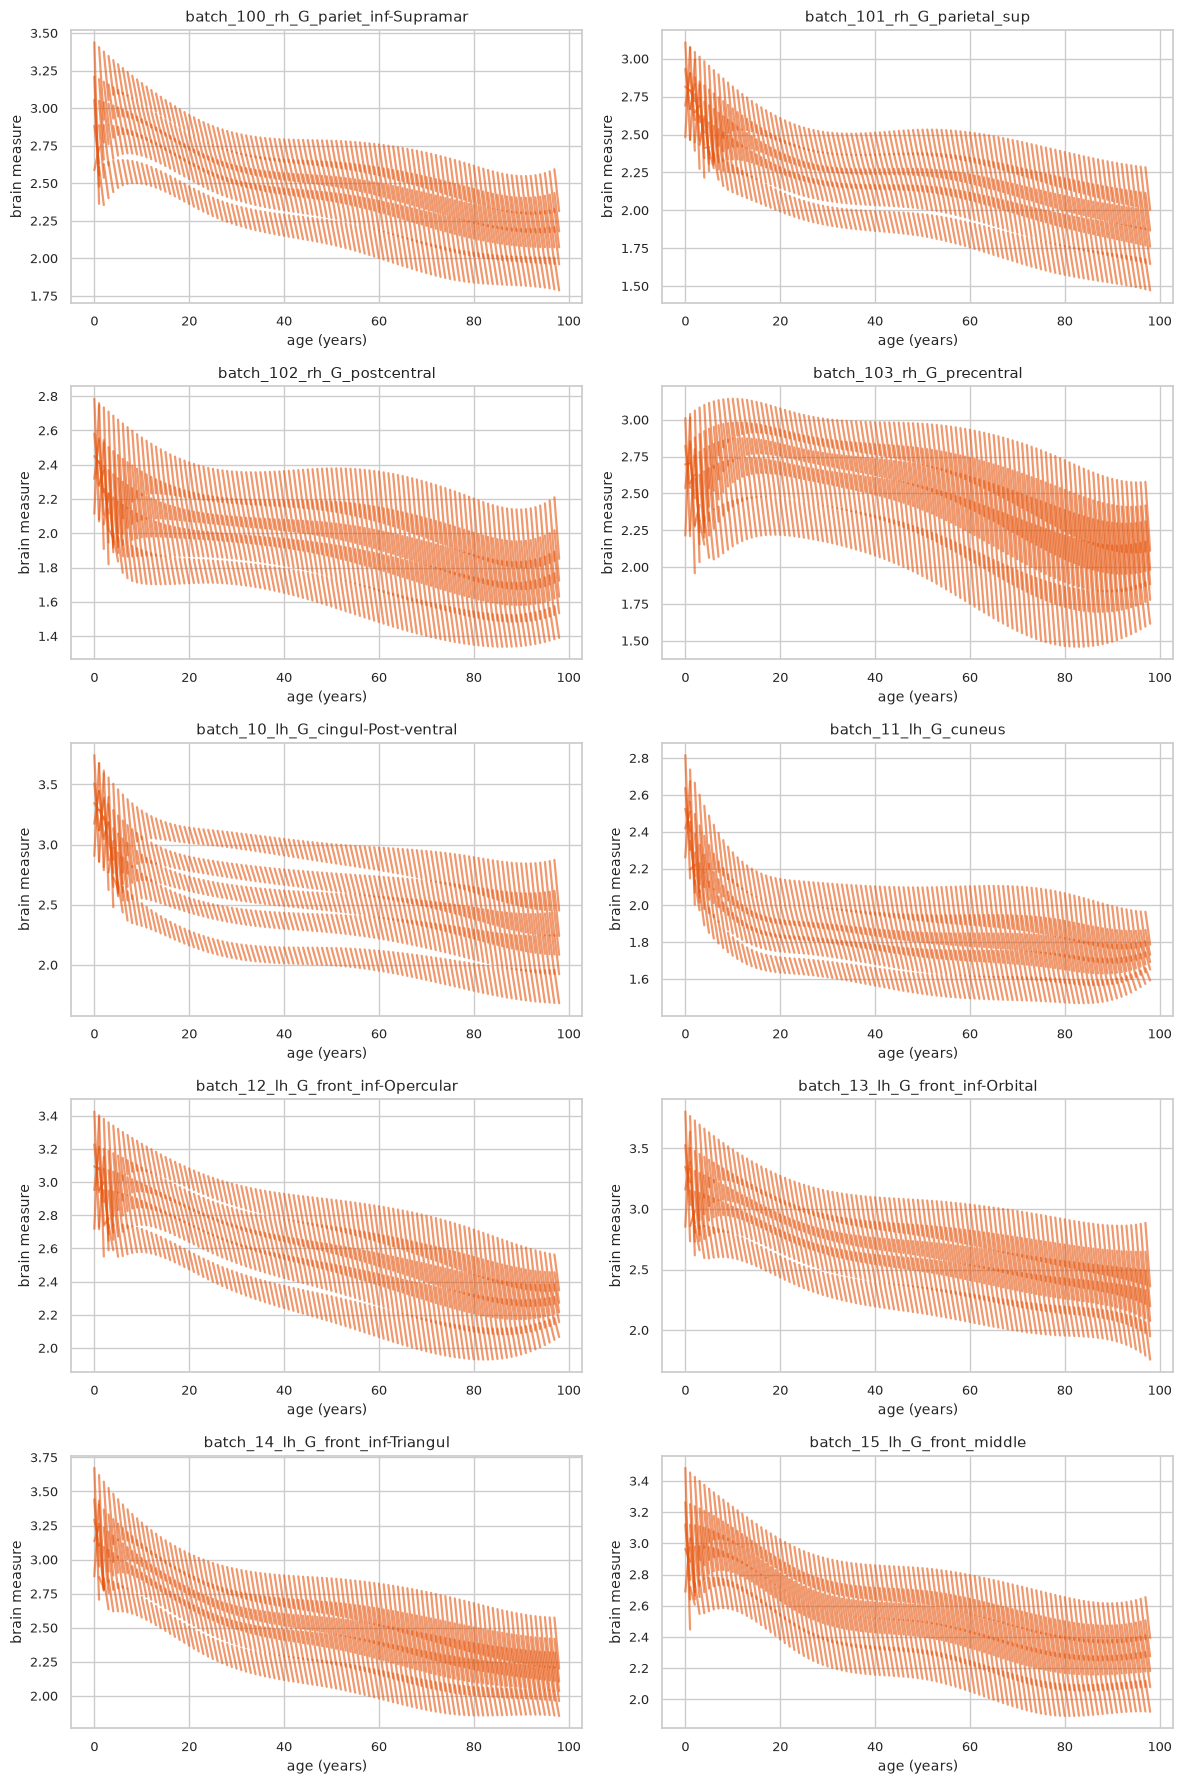

In [ ]:
selected_thrivelines = all_thrivelines[:10]

for region_thrivelines in selected_thrivelines:
    region_name = region_thrivelines['region_name'].iloc[0]
    response_var = region_thrivelines['response_var'].dropna().iloc[0]
    plot_thrivelines(
        public_model,
        thrivelines=region_thrivelines,
        centiles=CENTILES,
        covariate='age',
        response_vars=[response_var],
        show_figure=True,
        show_centile_labels=True,
    )
